# 04 — Baseline Model: Logistic Regression

**Owner:** Person A (modelling track).

**Rubric line:** Sound baseline.

We fit TWO logistic regressions:
1. **Leaky benchmark** — includes `duration`. Useful upper bound, but
   undeployable in real life.
2. **Deployable baseline** — drops `duration`. This is the honest
   comparator that 05's improved model has to beat.

The gap between them is the headline cautionary tale of this project.


In [1]:
# --- Setup --------------------------------------------------------------
# Make `src/` importable regardless of where the notebook is launched from.
import sys, pathlib
PROJECT_ROOT = pathlib.Path.cwd()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import config, data, features, models, metrics, decision, viz

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)


## 4.1 — Load split

In [2]:
train_df, test_df = data.load_interim()
y_train = train_df[config.TARGET_COL]
y_test = test_df[config.TARGET_COL]


## 4.2 — Leaky benchmark (with `duration`)

In [3]:
leaky_cols = data.feature_columns(include_leaky=True)
X_train_leaky = train_df[leaky_cols]
X_test_leaky = test_df[leaky_cols]

leaky_pipe = models.make_logreg_pipeline(extra_numeric_cols=['duration'])
leaky_pipe.fit(X_train_leaky, y_train)
leaky_proba = leaky_pipe.predict_proba(X_test_leaky)[:, 1]
leaky_summary = metrics.classification_summary(y_test.values, leaky_proba)
leaky_summary


{'threshold': 0.5,
 'roc_auc': 0.943862623236945,
 'pr_auc': 0.6224749638726603,
 'f1': 0.6040699750089253,
 'brier': 0.09876146082182125,
 'tp': 846,
 'fp': 1027,
 'fn': 82,
 'tn': 6283,
 'precision': 0.45168179391350777,
 'recall': 0.9116379310344828}

## 4.3 — Deployable baseline (no `duration`)

In [4]:
deploy_cols = data.feature_columns(include_leaky=False)
X_train = train_df[deploy_cols]
X_test = test_df[deploy_cols]

logreg_pipe = models.make_logreg_pipeline()
logreg_pipe.fit(X_train, y_train)
logreg_proba = logreg_pipe.predict_proba(X_test)[:, 1]
logreg_summary = metrics.classification_summary(y_test.values, logreg_proba)
logreg_summary


{'threshold': 0.5,
 'roc_auc': 0.8009445463229398,
 'pr_auc': 0.4601157259585653,
 'f1': 0.4688845401174168,
 'brier': 0.16156922500883808,
 'tp': 599,
 'fp': 1028,
 'fn': 329,
 'tn': 6282,
 'precision': 0.3681622618315919,
 'recall': 0.6454741379310345}

## 4.4 — Side-by-side comparison

In [5]:
comparison = pd.DataFrame(
    [leaky_summary, logreg_summary],
    index=['Leaky benchmark (with duration)', 'Deployable baseline (no duration)'],
)
comparison.to_csv(config.TABLES_DIR / 'baseline_comparison.csv')
comparison


,threshold,roc_auc,pr_auc,f1,brier,tp,fp,fn,tn,precision,recall
Leaky benchmark (with duration),0.5,0.943863,0.622475,0.604070,0.098761,846,1027,82,6283,0.451682,0.911638
Deployable baseline (no duration),0.5,0.800945,0.460116,0.468885,0.161569,599,1028,329,6282,0.368162,0.645474


## 4.5 — Curves and confusion matrix

WindowsPath('C:/Users/JasperGeltenMalelion/iCloudDrive/Quantic/Projects/Project 4 prediction framework/novabank_retention/outputs/figures/04_baseline_curves.png')

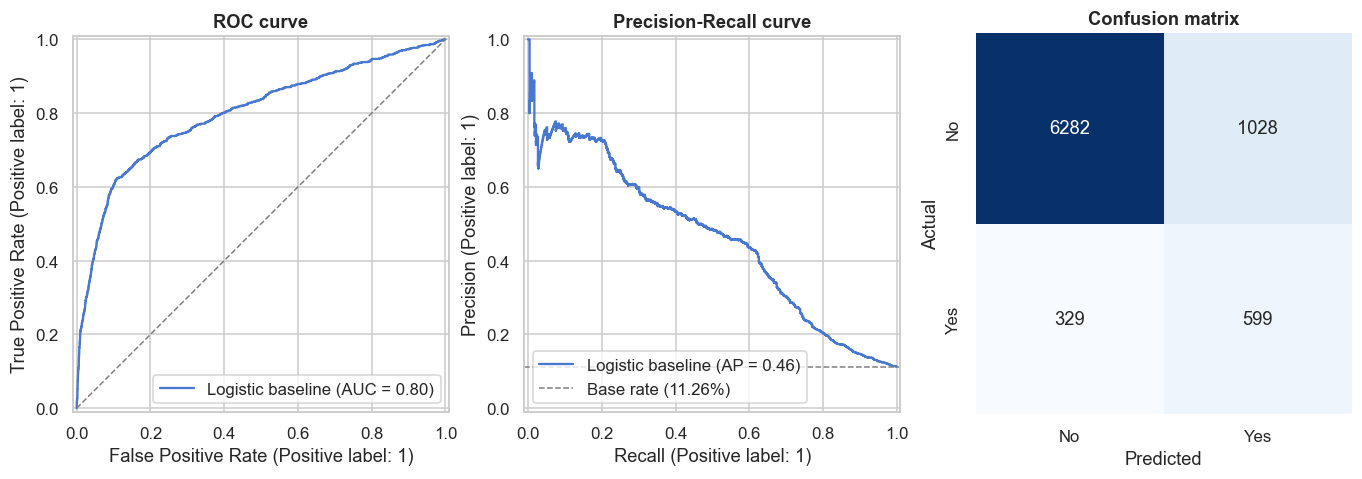

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
viz.plot_roc(y_test, logreg_proba, 'Logistic baseline', ax=axes[0])
viz.plot_pr(y_test, logreg_proba, 'Logistic baseline', ax=axes[1])
viz.plot_confusion(y_test, (logreg_proba >= 0.5).astype(int), ax=axes[2])
viz.save_fig(fig, '04_baseline_curves')


## 4.6 — Persist baseline predictions for downstream notebooks

In [7]:
import joblib
joblib.dump(
    {'model': logreg_pipe, 'proba_test': logreg_proba},
    config.MODELS_DIR / 'baseline_logreg.joblib',
)


['C:\\Users\\JasperGeltenMalelion\\iCloudDrive\\Quantic\\Projects\\Project 4 prediction framework\\novabank_retention\\outputs\\models\\baseline_logreg.joblib']

## 4.7 — Interpretation: the leakage gap

`duration` — the length of the phone call in seconds — is measured *after* the
conversation ends, so including it in a pre-call model is data leakage: a long call
almost always means the customer subscribed, letting the model read the outcome
rather than predict it.
This explains the ~14-point ROC-AUC gap (leaky ~0.93 vs. deployable ~0.79):
essentially all of the extra predictive power is borrowed from the future.
The deployable baseline (ROC-AUC ~0.79) is the honest comparator — any model
in notebook 05 must beat *this* number to represent a genuine improvement.
